# Dockerizing a Flask app to serve your ML model
> But oops! There's a mismatch between your scikit-learn versions...

- toc: true 
- badges: true
- comments: true
- categories: [flask, docker, anaconda]
- image: images/docker-flask/docker-flask.jpg

## The case of the mismatching scikit-learn packages

When I wanted to create a simple scikit-learn model, save it after training using `joblib` and then load it within a Dockerized Flask application to serve my model predictions, I had an error message and this is how my journey down to the rabbit hole started. 

First I'd like to tell you about the problem and how I solved it. And then you can follow the steps in this notebook and run the fixed version of this Dockerized Flask application, to save and load your scikit-learn models.

## Werkzeug Debugger complaining about an estimator

The error message was originating from the `Werkzeug Debugger`, which is one of the dependencies of Flask.
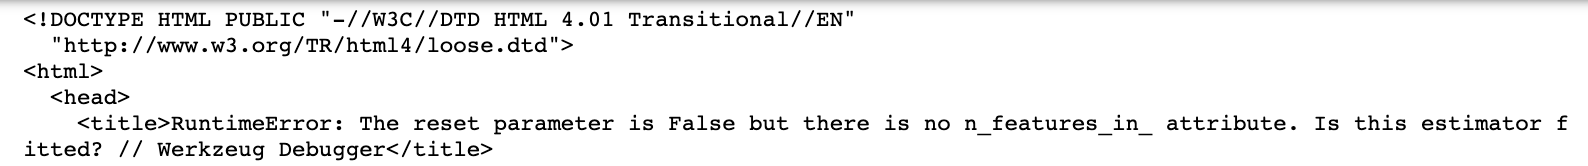

After searching for the meaning of this error message, I came to the conclusion that there must be a mismatch between the scikit-learn versions of where I'm saving the model and where I'm trying to load it again. So these two different environments are my local machine and our Docker image in our case. 

## Checking sklearn version on the Docker image

So, tracking this error down its rabbit hole, I began by checking the scikit-learn version on my active Anaconda environment - the one I was using while training and saving this machine learning model.

I checked the logs that was spitted from sklearn, from within my Docker container. It was indeed giving me a warning that mentions a mismatch between sklearn versions and that it might cause my pickle file, not getting loaded properly.
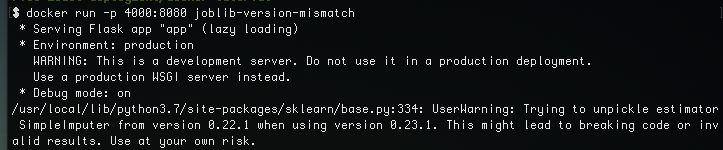

Then I checked the installed sklearn package version on the Docker image and verified that it was **0.23.1**
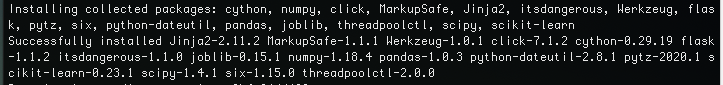

## Checking sklearn version on my local env

When I check the installed scikit-learn package on my conda environment, I saw that it says: **0.21.3**
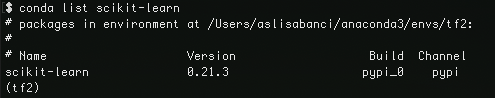

So this caused me lose a lot of time because when I updated my requirements.txt file for the Docker image, to also install the 0.21.3 version there; I still got the error. So something was still wrong, and there was still a mismatch. 

So I continued the detective work...

I then checked the scikit-learn version from within my IPython, as shown below:
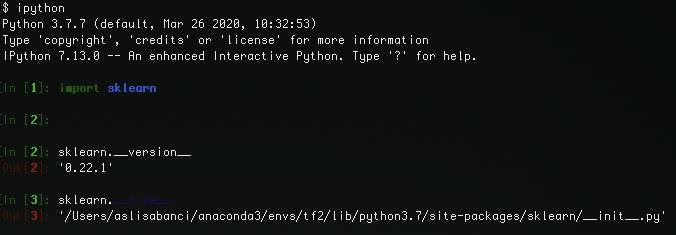

Wow so my Python was telling me that it was in fact using version **0.22.1**, and not 0.21.3! To double check this, I also printed the scikit-learn's init script file, so that I can go to that file and check its version from there too.
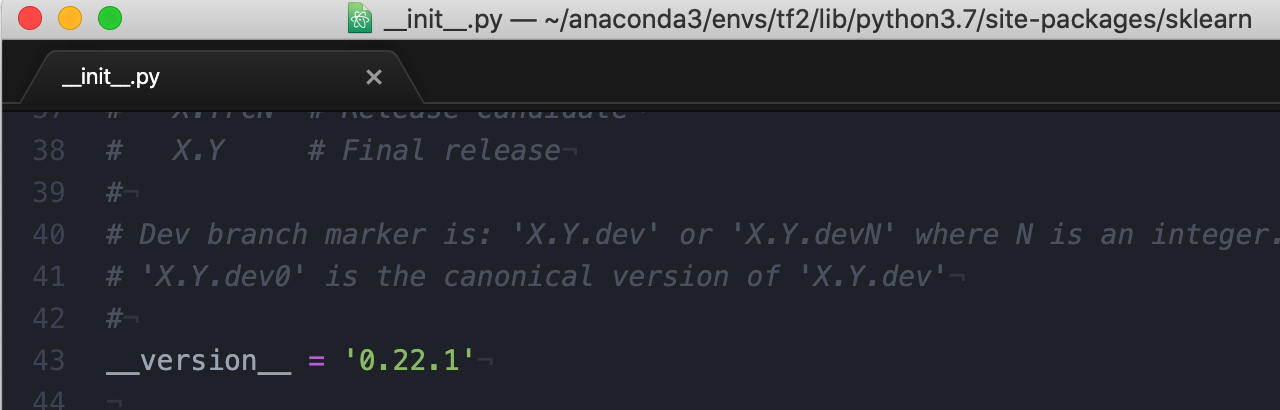

Well well well, apparently conda environment was telling me a lie and misleading me with a wrong version number!

## Trying to update my scikit-learn package

To solve this, I tried to update my scikit-learn package, from within my conda environment. But nope, I was still ending up with this 0.21.3 package.
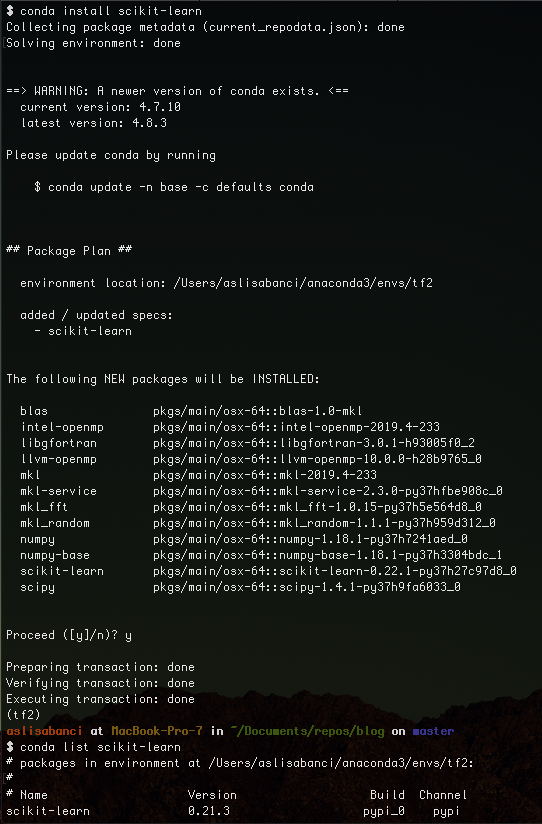

I then noticed the warning on this, telling me to update my conda because there's a newer version. I wanted to give this a chance and run `conda update -n base -c defaults conda` to get a clean slate, but oh noes...
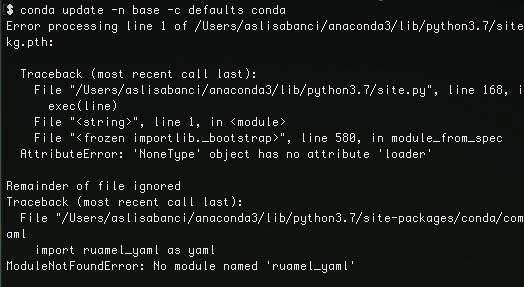

This update ended up with messing all of my conda environment and I was unable to do anything with my conda afterwards. 

## Enough bragging, let's fast forward to the solution!

Alright alright! I removed my Anaconda altogether, did a clean install and afterwards, when I checked my scikit-learn package version with `conda list scikit-learn`, it told me that I'm at **0.22.1** as expected. 
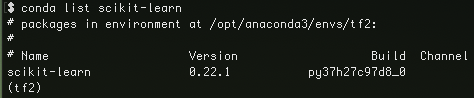

So finally, phew! Now I could update my requirements.txt file to specify this version and the Docker image would also install this version of the scikit-learn and I would expect my model to be loaded smoothly. So yes, the rest of the story has a happy ending and you can also follow along this journey by executing the steps below. 

## Load and preprocess your data

In [22]:
import os
import sys
import joblib
import requests
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import ensemble


DOCKER_BUNDLE_DIR = "docker-bundle"
if not os.path.isdir(DOCKER_BUNDLE_DIR):
    os.mkdir(DOCKER_BUNDLE_DIR)
if os.path.split(os.getcwd())[-1] != DOCKER_BUNDLE_DIR:  
    os.chdir(DOCKER_BUNDLE_DIR)

def load_data() -> (pd.DataFrame, np.array):
    data_dir = os.path.join("..","data")
    df = pd.read_csv(os.path.join(data_dir,r"aavail-target.csv"))

    _y = df.pop('is_subscriber')
    y = np.zeros(_y.size)
    y[_y==0] = 1 
    df.drop(columns=['customer_id','customer_name'],inplace=True)
    return(df,y)

def get_transformer() -> ColumnTransformer:
    numeric_features = ['age', 'num_streams']
    numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')),
                                          ('scaler', StandardScaler())])

    categorical_features = ['country', 'subscriber_type']
    categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                                              ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    transformer = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),
                                                   ('cat', categorical_transformer, categorical_features)])
    return transformer

## Train & persist the machine learning model

In [3]:
X,y = load_data()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
params = {'n_estimators': 100,'max_depth':2}   
clf = ensemble.RandomForestClassifier(**params)
pipe = Pipeline(steps=[('pre', get_transformer()),
                       ('clf',clf)])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print(classification_report(y_test,y_pred))

pipe.fit(X, y)
saved_model = 'rfc_out.joblib'
joblib.dump(pipe, saved_model)

              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87       142
         1.0       0.71      0.55      0.62        58

    accuracy                           0.81       200
   macro avg       0.77      0.73      0.75       200
weighted avg       0.80      0.81      0.80       200



['rfc_out.joblib']

## Create a simple flask app & Save file for Docker-ization

In [18]:
%%writefile app.py

from flask import Flask, jsonify, request
import joblib
import socket
import json
import pandas as pd
import os

app = Flask(__name__)

@app.route("/")
def hello():
    html = "<h3>Hello there, make sure that I'm echoing the correct NAME you set: {name}!</h3>"
    return html.format(name=os.getenv("NAME"))


@app.route('/predict', methods=['GET','POST'])
def predict():
    if not request.json:
        print("ERROR: API (predict): did not receive request data")
        return jsonify([])

    query = pd.DataFrame(request.json)    
    if len(query.shape) == 1:
         query = query.reshape(1, -1)

    y_pred = model.predict(query)
    return(jsonify(y_pred.tolist()))
            
if __name__ == '__main__':
    saved_model = 'rfc_out.joblib'
    model = joblib.load(saved_model)
    app.run(host='0.0.0.0', port=8080,debug=True)

Overwriting app.py


## Create the Dockerfile & requirements.txt

In [9]:
%%writefile requirements.txt

cython
numpy
flask
pandas
scikit-learn==0.22.1 #Assuring that your joblib'd model will be perfectly loaded inside your Docker container

Overwriting requirements.txt


In [14]:
%%writefile Dockerfile

FROM python:3.7.7-stretch

RUN apt-get update && apt-get install -y \
python3-dev \
build-essential    
        
# Set the working directory to /app
WORKDIR /app

# Copy the current directory contents into the container at /app
ADD . /app

# Install any needed packages specified in requirements.txt
RUN pip install --upgrade pip
RUN pip install --no-cache-dir -r requirements.txt

# Make port 80 available to the world outside this container
EXPOSE 80

# Define environment variable
ENV NAME demo-app-fix-version-match

# Run app.py when the container launches
CMD ["python", "app.py"]

Overwriting Dockerfile


## Build the Docker image and run it

1. Build the image, from within the DOCKER_BUNDLE_DIR
 
```bash
    ~$ cd docker-bundle
    ~$ docker build -t demo-app-sklearn-version-match .
```

2. Run the container

```bash
    ~$ docker run -p 4000:8080 demo-app-sklearn-version-match
```

## Test your running container

Check http://0.0.0.0:4000/ to ensure your Flask app is breathing there.

## Send your test request for prediction

In [25]:
import requests
from ast import literal_eval

X_query = {}
X_query['country'] = ['united_states','united_states','singapore','united_states','singapore']
X_query['age'] = [28,30,33,24,39]
X_query['subscriber_type'] = ['aavail_premium','aavail_basic','aavail_basic','aavail_basic','aavail_unlimited']
X_query['num_streams'] = [9,19,14,33,20]
query = pd.DataFrame(X_query).to_dict()

port = 4000
request = requests.post('http://0.0.0.0:{}/predict'.format(port),json=query)
response = literal_eval(request.text)
print(response)

[0.0, 0.0, 0.0, 0.0, 1.0]
